# Import Libraries

In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
%pip install matplotlib
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 996.2 kB/s eta 0:00:08
   -- ------------------------------------- 0.5/8.3 MB 996.2 kB/s eta 0:00:08
   --- ------------------------------------ 0.8/8.3 MB 841.0 kB/s eta 0:00:09
   --- ------------------------------------ 0.8/8.3 MB 841.0 kB/s eta 0:00:09
   ----- ---------------------------------- 1.0/8.3 MB 848.5 kB/s eta 0:00:09
   ----- ---------------------------------- 1.0/8.3 MB 848.5 kB/s eta 0:00:09
   ------ --------------------------------- 1.3/8.3 MB 795.3 kB/s eta 0:00:09
   ------ --------------------------------- 1.3/8.3 MB 795.3 kB/s eta 0:00:09
   ------- -------------------------------- 1.6/8.3 MB 698.3 kB/s eta 0:00:10
   ------- --

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


# Load Dataset

In [3]:
# Load dataset
df = pd.read_csv('../data/raw/data.csv', encoding='latin-1')

print("Dataset loaded successfully!")
print(f"Total rows    : {df.shape[0]:,}")
print(f"Total columns : {df.shape[1]}")

Dataset loaded successfully!
Total rows    : 541,909
Total columns : 8


In [4]:
# First look
print("=== First 5 rows ===")
df.head()

=== First 5 rows ===


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
# Column info
print("=== Column Names and Types ===")
print(df.dtypes)

=== Column Names and Types ===
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object


In [6]:
# Basic statistics
print(f"Dataset Shape: {df.shape}")
print("\n=== Basic Statistics ===")
df.describe()

Dataset Shape: (541909, 8)

=== Basic Statistics ===


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [7]:
# Missing values
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percent': missing_percent
})

print(missing_df[missing_df['Missing Count'] > 0])

=== Missing Values ===
             Missing Count  Missing Percent
Description           1454         0.268311
CustomerID          135080        24.926694


In [10]:
# Unique values
print(f"Unique Customers : {df['CustomerID'].nunique():,}")
print(f"Unique Products  : {df['StockCode'].nunique():,}")
print(f"Unique Countries : {df['Country'].nunique():,}")
print(f"\nDate Range:")
print(f"From : {df['InvoiceDate'].min()}")
print(f"To   : {df['InvoiceDate'].max()}")

Unique Customers : 4,372
Unique Products  : 4,070
Unique Countries : 38

Date Range:
From : 1/10/2011 10:04
To   : 9/9/2011 9:52


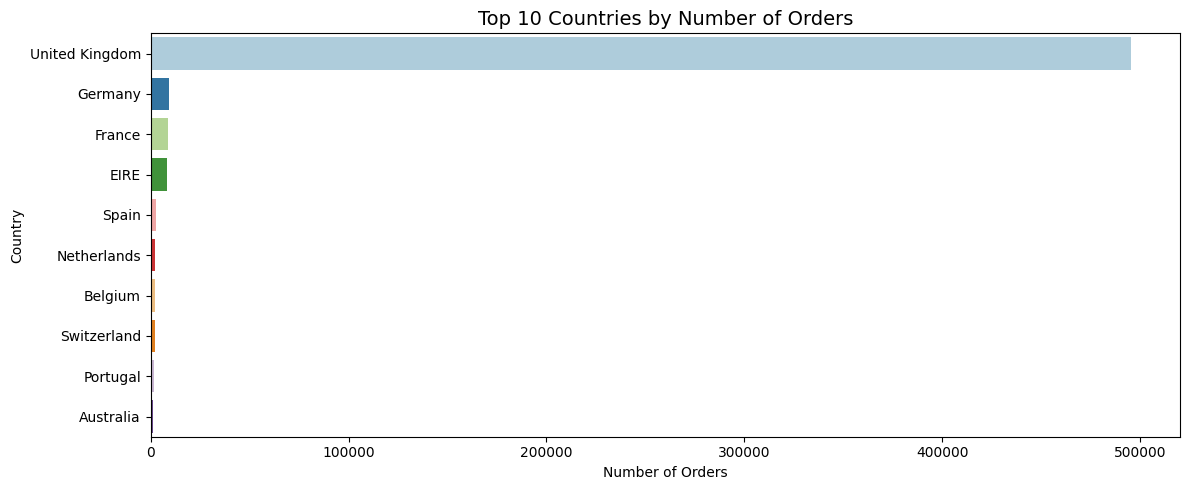

Chart saved to reports folder


In [17]:
# Top countries
plt.figure(figsize=(12, 5))
top_countries = df['Country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Paired')
plt.title('Top 10 Countries by Number of Orders', fontsize=14)
plt.xlabel('Number of Orders')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('../reports/top_countries.png')
plt.show()
print("Chart saved to reports folder")

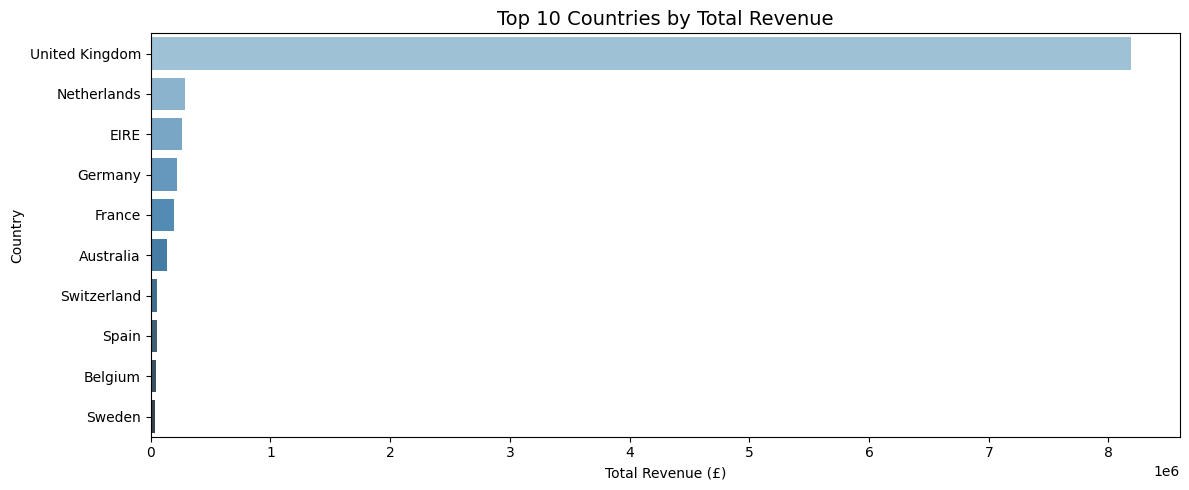

In [19]:
# Add revenue column and plot
df['Revenue'] = df['Quantity'] * df['UnitPrice']

plt.figure(figsize=(12, 5))
revenue_by_country = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=revenue_by_country.values, y=revenue_by_country.index, palette='Blues_d')
plt.title('Top 10 Countries by Total Revenue', fontsize=14)
plt.xlabel('Total Revenue (£)')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('../reports/revenue_by_country.png')
plt.show()

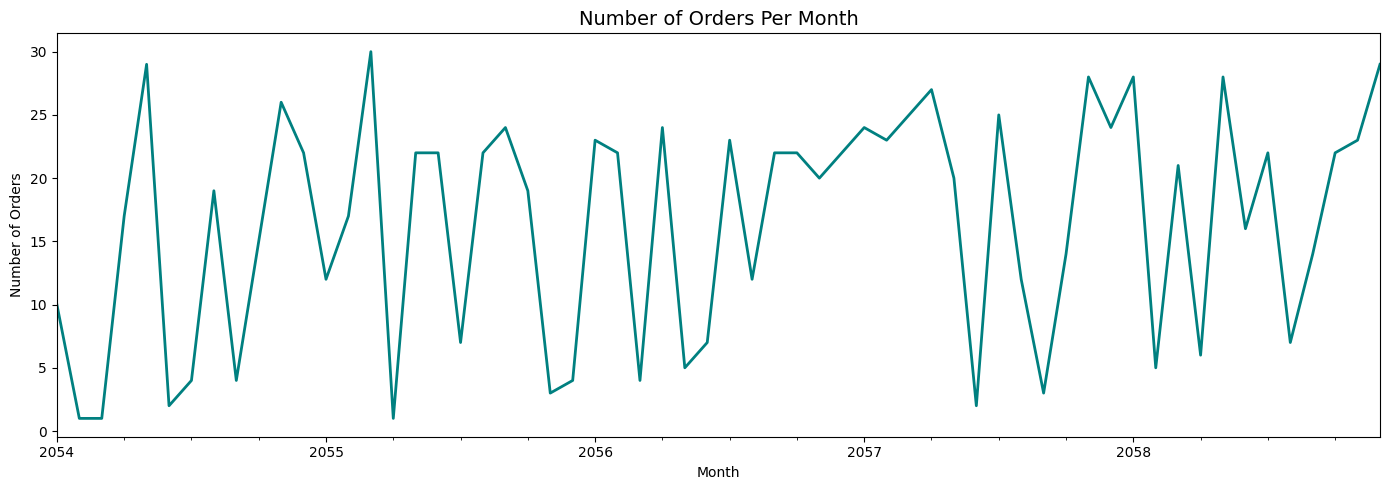

Chart saved to reports folder


In [25]:
# Orders over time
df['InvoiceNo'] = pd.to_datetime(df['InvoiceNo'])
df['Month'] = df['InvoiceNo'].dt.to_period('M')

monthly_orders = df.groupby('Month')['InvoiceNo'].nunique()

plt.figure(figsize=(14, 5))
monthly_orders.plot(kind='line', color='teal', linewidth=2)
plt.title('Number of Orders Per Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('../reports/monthly_orders.png')
plt.show()
print("Chart saved to reports folder")

In [27]:
# Summary
print("=" * 50)
print("EDA SUMMARY — ShopLens")
print("=" * 50)
print(f"Total transactions   : {df.shape[0]:,}")
print(f"Total customers      : {df['CustomerID'].nunique():,}")
print(f"Total products       : {df['StockCode'].nunique():,}")
print(f"Total countries      : {df['Country'].nunique():,}")
print(f"Total revenue        : £{df['Revenue'].sum():,.2f}")
print(f"Missing CustomerIDs  : {df['CustomerID'].isnull().sum():,}")
print(f"Negative quantities  : {(df['Quantity'] < 0).sum():,}")
print(f"Date range           : {df['InvoiceNo'].min().date()} to {df['InvoiceDate'].max().date()}")
print("=" * 50)
print("EDA complete! Ready for preprocessing.")

EDA SUMMARY — ShopLens
Total transactions   : 541,909
Total customers      : 4,372
Total products       : 4,070
Total countries      : 38
Total revenue        : £9,747,747.93
Missing CustomerIDs  : 135,080
Negative quantities  : 10,624
Date range           : 2054-01-13 to 2011-12-09
EDA complete! Ready for preprocessing.
